In [1]:
pip install ucimlrepo

Note: you may need to restart the kernel to use updated packages.


In [2]:
def purity_score(y_true, y_pred):
    """
    Calcola la purity tra etichette vere (y_true) e assegnazioni di clustering (y_pred).
    
    Parameters:
    - y_true: array-like, etichette reali
    - y_pred: array-like, etichette di clustering
    
    Returns:
    - purity: float, valore tra 0 e 1
    """
    from sklearn.metrics import confusion_matrix

    # Matrice di contingenza: righe = classi vere, colonne = cluster
    contingency_matrix = confusion_matrix(y_true, y_pred)
    
    # Somma dei massimi per ogni colonna (cluster)
    max_per_cluster = np.max(contingency_matrix, axis=0)
    
    # Purezza = somma dei massimi / totale dei campioni
    purity = np.sum(max_per_cluster) / np.sum(contingency_matrix)
    
    return purity

In [3]:
from ucimlrepo import fetch_ucirepo 
  
# fetch dataset 
wine_quality = fetch_ucirepo(id=186) 
  
# data (as pandas dataframes) 
X = wine_quality.data.features 
Y = wine_quality.data.targets  

In [4]:
import numpy as np
import pandas as pd

# Conversione in matrici NumPy
x = X.to_numpy()   # oppure: x.values
y = Y.to_numpy()   # oppure: y.values

print("Shape di x:", x.shape)
print("Shape di y:", y.shape)
print(x)
print(y)
data_matrix=x
ground_truth=y

Shape di x: (6497, 11)
Shape di y: (6497, 1)
[[ 7.4   0.7   0.   ...  3.51  0.56  9.4 ]
 [ 7.8   0.88  0.   ...  3.2   0.68  9.8 ]
 [ 7.8   0.76  0.04 ...  3.26  0.65  9.8 ]
 ...
 [ 6.5   0.24  0.19 ...  2.99  0.46  9.4 ]
 [ 5.5   0.29  0.3  ...  3.34  0.38 12.8 ]
 [ 6.    0.21  0.38 ...  3.26  0.32 11.8 ]]
[[5]
 [5]
 [5]
 ...
 [6]
 [7]
 [6]]


<h2>K-means</h2>

In [5]:
from sklearn.cluster import KMeans

n_clusters = 9
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(data_matrix)
cluster_assignments = kmeans.labels_
centroids = kmeans.cluster_centers_


<h3>PCA decomposition</h3>

In [6]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_matrix)
centroids_2d = pca.transform(centroids)


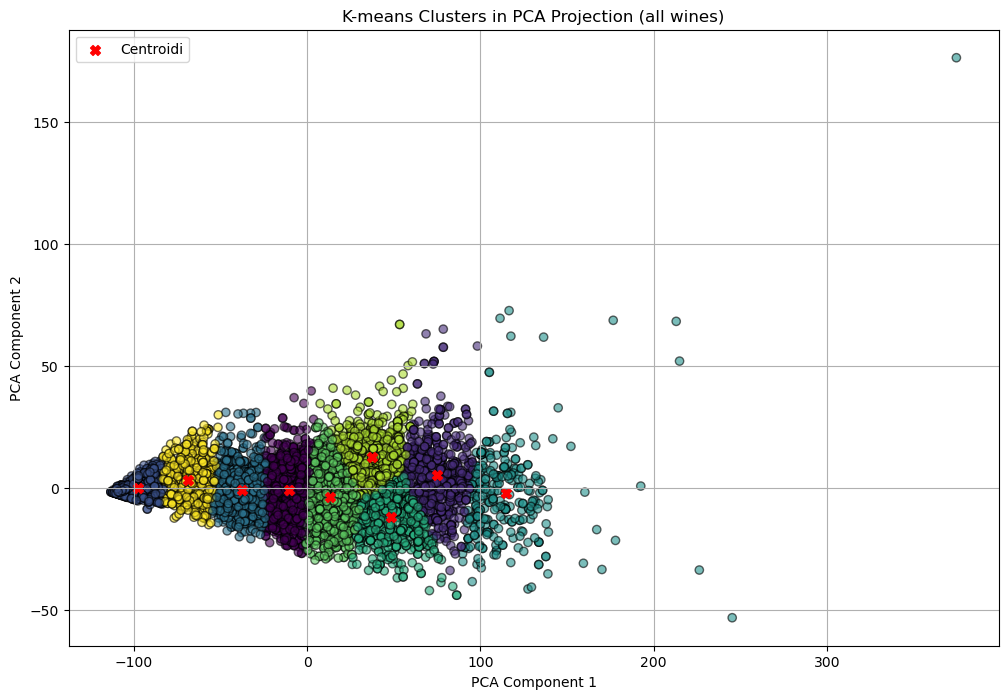

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))
plt.scatter(data_2d[:, 0], data_2d[:, 1],
            c=cluster_assignments, cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c="red", marker="X", s=50, label="Centroidi")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-means Clusters in PCA Projection (all wines)")
plt.legend()
plt.grid(True)
plt.savefig("K-means Clusters in PCA Projection (all wines).pdf", format="pdf")
plt.show()


In [8]:
print("Purity score of k-means:", purity_score(ground_truth,cluster_assignments))

Purity score of k-means: 0.4405110050792674


<h2>Gaussian Mixtures </h2>

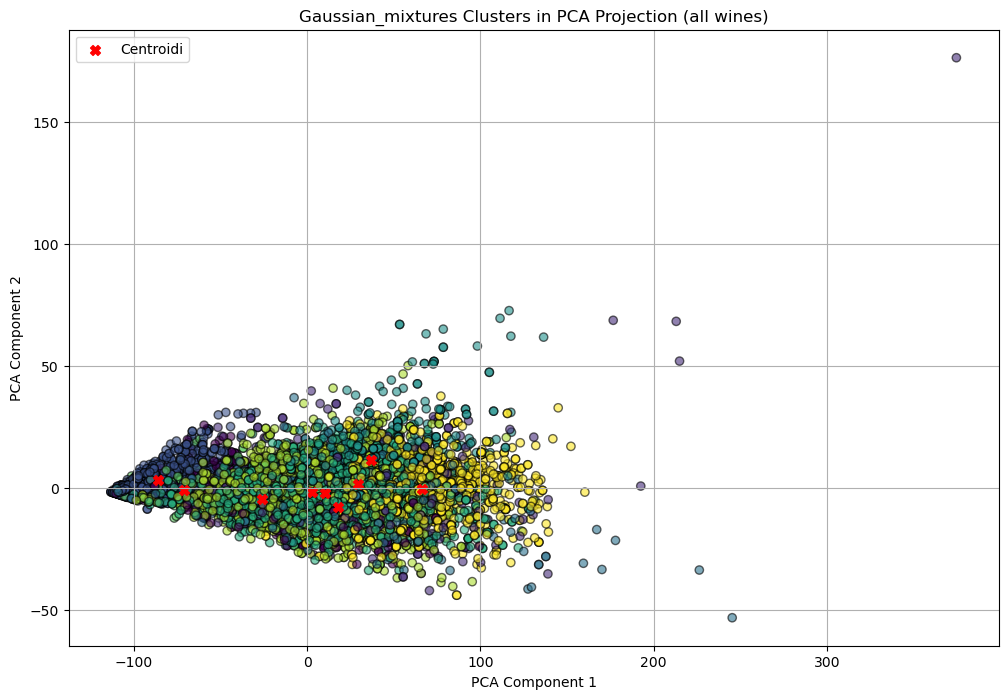

Purity score of Gaussian_Mixtures: 0.5033092196398338


In [9]:
from sklearn.mixture import GaussianMixture
n_clusters = 9

gmm = GaussianMixture(n_components=n_clusters)

gmm.fit(data_matrix)

soft_assignments = gmm.predict_proba(data_matrix)

hard_assignments = gmm.predict(data_matrix)

centroids = gmm.means_

#PCA and plotting:

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_matrix)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(12, 8))
plt.scatter(data_2d[:, 0], data_2d[:, 1],
            c=hard_assignments, cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c="red", marker="X", s=50, label="Centroidi")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Gaussian_mixtures Clusters in PCA Projection (all wines)")
plt.legend()
plt.grid(True)
plt.savefig("Gaussian_mixtures Clusters in PCA Projection (all wines).pdf", format="pdf")

plt.show()

print("Purity score of Gaussian_Mixtures:", purity_score(ground_truth,hard_assignments))

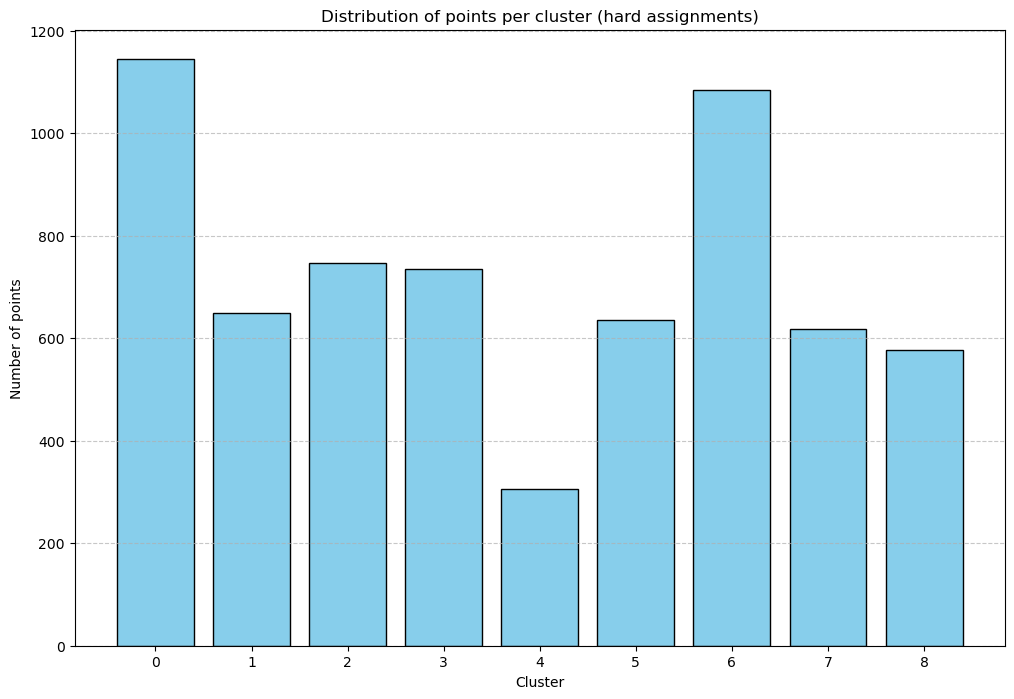

In [10]:
unique_clusters, counts = np.unique(cluster_assignments, return_counts=True)

plt.figure(figsize=(12,8))
plt.bar(unique_clusters, counts, color="skyblue", edgecolor="black")
plt.xlabel("Cluster")
plt.ylabel("Number of points")
plt.title("Distribution of points per cluster (hard assignments)")
plt.xticks(unique_clusters)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.savefig("Distribution of points per cluster (hard assignments).pdf", format="pdf")

plt.show()


<h2>What if we divide red and white wines?</h2>

<h2>Red wines</h2>

In [11]:
import pandas as pd
import numpy as np

df = pd.read_csv("winequality-red.csv", sep=";")
print(df.columns.tolist())

# Seleziona le colonne che ti interessano
selected_columns = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates","alcohol"]

# Crea la matrice NumPy
data_matrix = df[selected_columns].to_numpy()
quality_selected_column=["quality"]
ground_truth=df[quality_selected_column].to_numpy()
print("Shape della matrice:", data_matrix.shape)
print(data_matrix)


['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Shape della matrice: (1599, 11)
[[ 7.4    0.7    0.    ...  3.51   0.56   9.4  ]
 [ 7.8    0.88   0.    ...  3.2    0.68   9.8  ]
 [ 7.8    0.76   0.04  ...  3.26   0.65   9.8  ]
 ...
 [ 6.3    0.51   0.13  ...  3.42   0.75  11.   ]
 [ 5.9    0.645  0.12  ...  3.57   0.71  10.2  ]
 [ 6.     0.31   0.47  ...  3.39   0.66  11.   ]]


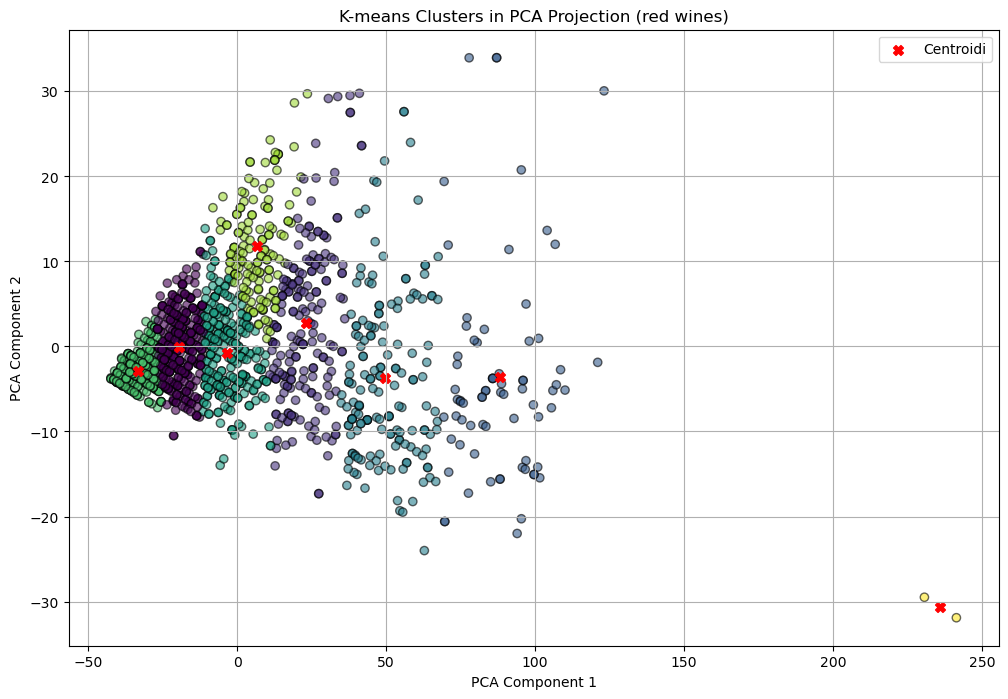

Purity score of k-means: 0.4878048780487805


In [12]:

n_clusters = 8
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(data_matrix)
cluster_assignments = kmeans.labels_
centroids = kmeans.cluster_centers_

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_matrix)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(12, 8))
plt.scatter(data_2d[:, 0], data_2d[:, 1],
            c=cluster_assignments, cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c="red", marker="X", s=50, label="Centroidi")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-means Clusters in PCA Projection (red wines)")
plt.legend()
plt.grid(True)
plt.savefig("K-means Clusters in PCA Projection (red wines).pdf", format="pdf")

plt.show()

print("Purity score of k-means:", purity_score(ground_truth,cluster_assignments))

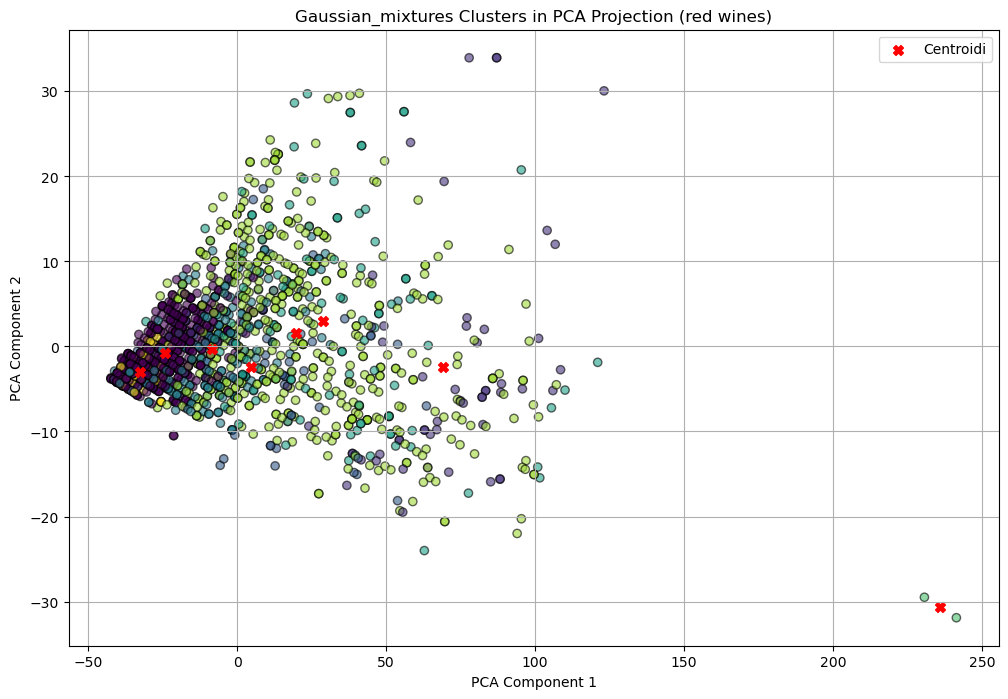

Purity score of Gaussian_Mixtures: 0.5003126954346466


In [13]:
n_clusters = 8

gmm = GaussianMixture(n_components=n_clusters)

gmm.fit(data_matrix)

soft_assignments = gmm.predict_proba(data_matrix)

hard_assignments = gmm.predict(data_matrix)

centroids = gmm.means_

#PCA and plotting:

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_matrix)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(12, 8))
plt.scatter(data_2d[:, 0], data_2d[:, 1],
            c=hard_assignments, cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c="red", marker="X", s=50, label="Centroidi")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Gaussian_mixtures Clusters in PCA Projection (red wines)")
plt.legend()
plt.grid(True)
plt.savefig("Gaussian_mixtures Clusters in PCA Projection (red wines).pdf", format="pdf")

plt.show()

print("Purity score of Gaussian_Mixtures:", purity_score(ground_truth,hard_assignments))

<h2>White wines</h2>

In [14]:
import pandas as pd
import numpy as np

df = pd.read_csv("winequality-white.csv", sep=";")
print(df.columns.tolist())

# Seleziona le colonne che ti interessano
selected_columns = ["fixed acidity", "volatile acidity", "citric acid", "residual sugar", "chlorides", "free sulfur dioxide", "total sulfur dioxide", "density", "pH", "sulphates","alcohol"]

# Crea la matrice NumPy
data_matrix = df[selected_columns].to_numpy()
quality_selected_column=["quality"]
ground_truth=df[quality_selected_column].to_numpy()
print("Shape della matrice:", data_matrix.shape)
print(data_matrix)

['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol', 'quality']
Shape della matrice: (4898, 11)
[[ 7.    0.27  0.36 ...  3.    0.45  8.8 ]
 [ 6.3   0.3   0.34 ...  3.3   0.49  9.5 ]
 [ 8.1   0.28  0.4  ...  3.26  0.44 10.1 ]
 ...
 [ 6.5   0.24  0.19 ...  2.99  0.46  9.4 ]
 [ 5.5   0.29  0.3  ...  3.34  0.38 12.8 ]
 [ 6.    0.21  0.38 ...  3.26  0.32 11.8 ]]


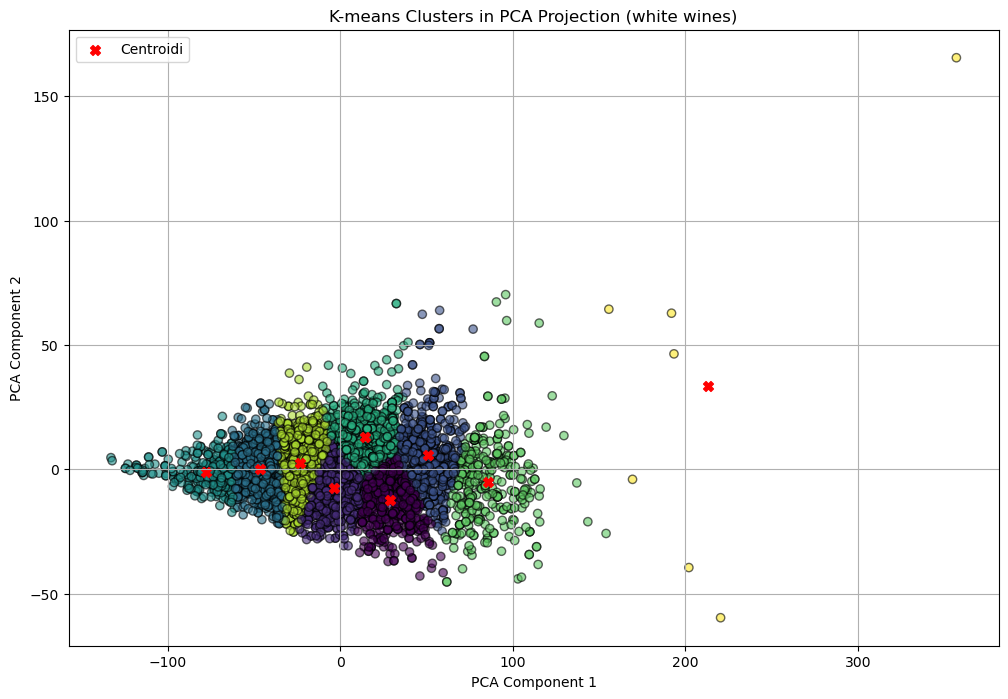

Purity score of k-means: 0.45345038791343406


In [15]:
n_clusters = 9
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
kmeans.fit(data_matrix)
cluster_assignments = kmeans.labels_
centroids = kmeans.cluster_centers_

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_matrix)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(12, 8))
plt.scatter(data_2d[:, 0], data_2d[:, 1],
            c=cluster_assignments, cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c="red", marker="X", s=50, label="Centroidi")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("K-means Clusters in PCA Projection (white wines)")
plt.legend()
plt.grid(True)
plt.savefig("K-means Clusters in PCA Projection (white wines).pdf", format="pdf")

plt.show()

print("Purity score of k-means:", purity_score(ground_truth,cluster_assignments))

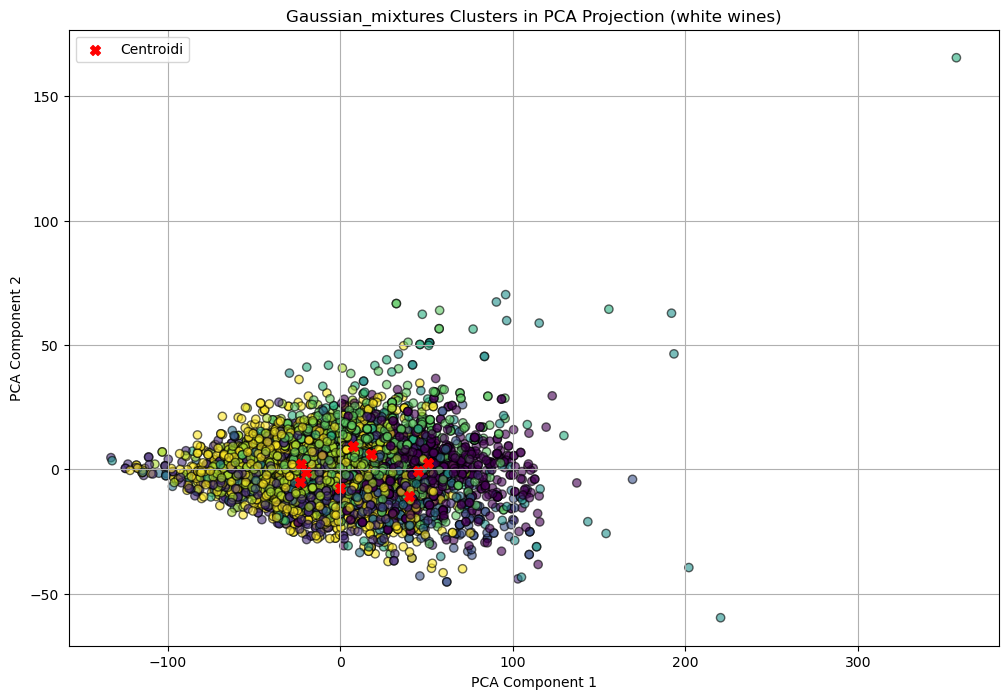

Purity score of Gaussian_Mixtures: 0.47733768885259287


In [16]:
n_clusters = 9

gmm = GaussianMixture(n_components=n_clusters)

gmm.fit(data_matrix)

soft_assignments = gmm.predict_proba(data_matrix)

hard_assignments = gmm.predict(data_matrix)

centroids = gmm.means_

#PCA and plotting:

pca = PCA(n_components=2)
data_2d = pca.fit_transform(data_matrix)
centroids_2d = pca.transform(centroids)

plt.figure(figsize=(12, 8))
plt.scatter(data_2d[:, 0], data_2d[:, 1],
            c=hard_assignments, cmap="viridis", alpha=0.6, edgecolor="k")
plt.scatter(centroids_2d[:, 0], centroids_2d[:, 1],
            c="red", marker="X", s=50, label="Centroidi")

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("Gaussian_mixtures Clusters in PCA Projection (white wines)")
plt.legend()
plt.grid(True)
plt.savefig("Gaussian_mixtures Clusters in PCA Projection (white wines).pdf", format="pdf")

plt.show()

print("Purity score of Gaussian_Mixtures:", purity_score(ground_truth,hard_assignments))